# 🏦 DARCRAYS — AI-Powered Alternate Credit Scoring
### Pipeline: Raw Transactions → Feature Engineering → GMM → XGBoost → CIBIL Score (300–900)

## ✅ Correct Flow
```
1 Lakh Users (complete raw data)
         ↓
Feature Engineering (62 features from raw transactions)
         ↓
GMM trains on FULL 1 lakh  ✅
         ↓
Same 1 lakh mein 30% missing add karo
         ↓
GMM se missing fill karo (soft cluster imputation)
         ↓
QA Check: filled values vs original values compare karo  ✅
         ↓
XGBoost trains on FULL 1 lakh (imputed)  ✅
         ↓
10k NEW test users → GMM impute → XGBoost → Credit Score
```

## 📦 Step 0 — Install & Import

In [1]:
import subprocess, sys
pkgs = ['xgboost','shap','scikit-learn','pandas','numpy','matplotlib','seaborn','joblib']
for p in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', p, '-q'], check=False)
print('✅ packages ready')

✅ packages ready


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json, joblib, os, time
warnings.filterwarnings('ignore')

from numpy.random import default_rng
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              r2_score, confusion_matrix, roc_auc_score)
from sklearn.decomposition import PCA
import xgboost as xgb

os.makedirs('models',  exist_ok=True)
os.makedirs('outputs', exist_ok=True)

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

STRUCTURAL_ZERO_COLS = [
    'monthly_avg_business_credit','pos_txn_count_monthly_avg',
    'gst_payment_count','business_account_avg_balance',
    'trade_credit_utilisation','receivables_turnover_days',
]
META_COLS   = ['user_id', 'user_type']
TARGET_COLS = ['credit_score', 'risk_band']

def to_band(scores):
    scores = np.asarray(scores)
    return np.where(scores>=750,'A',np.where(scores>=650,'B',np.where(scores>=550,'C','D')))

print(f'✅ imports done | XGBoost {xgb.__version__}')

✅ imports done | XGBoost 3.2.0


## 📂 Step 1 — Load Data
> ⚠️ **Pehle yeh run karo (ek baar):**
> ```
> py generate_raw_data.py
> py Feature_engineering.py
> ```
> Phir yahan se notebook chalao.

In [3]:
print('Loading datasets ...')
t0 = time.time()

df_all     = pd.read_csv('data/all_users.csv')
df_gt      = pd.read_csv('data/all_users_ground_truth.csv')
df_test    = pd.read_csv('data/test.csv')
df_test_gt = pd.read_csv('data/test_ground_truth.csv')

with open('data/feat_cols_clean.json') as f:
    feat_cols = json.load(f)

print(f'✅ Loaded in {time.time()-t0:.1f}s')
print(f'\n  all_users.csv  : {df_all.shape}')
print(f'  test.csv       : {df_test.shape}')
print(f'  Features       : {len(feat_cols)}')
print(f'  Score range    : {df_all["credit_score"].min()} – {df_all["credit_score"].max()}')
print(f'  Mean score     : {df_all["credit_score"].mean():.0f}')
print(f'\n  Bands:\n{df_all["risk_band"].value_counts().sort_index().to_string()}')
print(f'\n  User types:\n{df_all["user_type"].value_counts().to_string()}')

Loading datasets ...
✅ Loaded in 1.8s

  all_users.csv  : (100000, 68)
  test.csv       : (10000, 66)
  Features       : 64
  Score range    : 436 – 818
  Mean score     : 628

  Bands:
risk_band
A     3060
B    43247
C    34187
D    19506

  User types:
user_type
salaried_private    34857
shopkeeper          20226
businessman         18037
salaried_govt       14886
self_employed       11994


## 📊 Step 2 — EDA

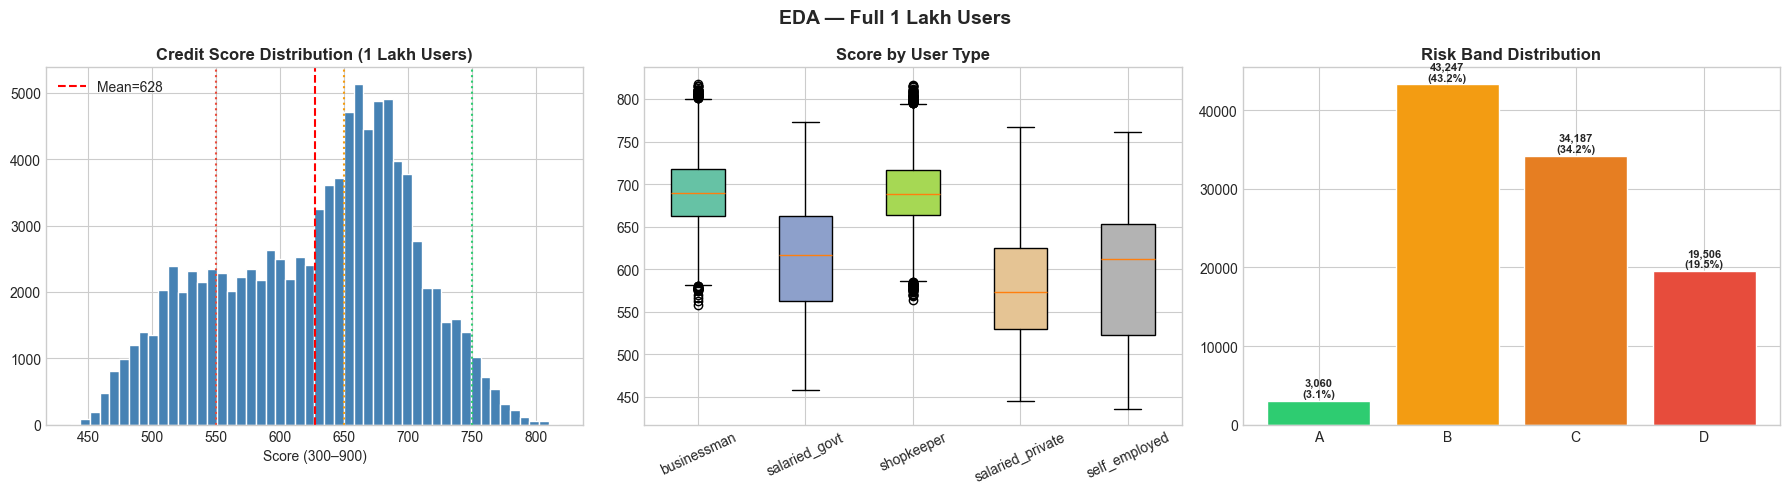

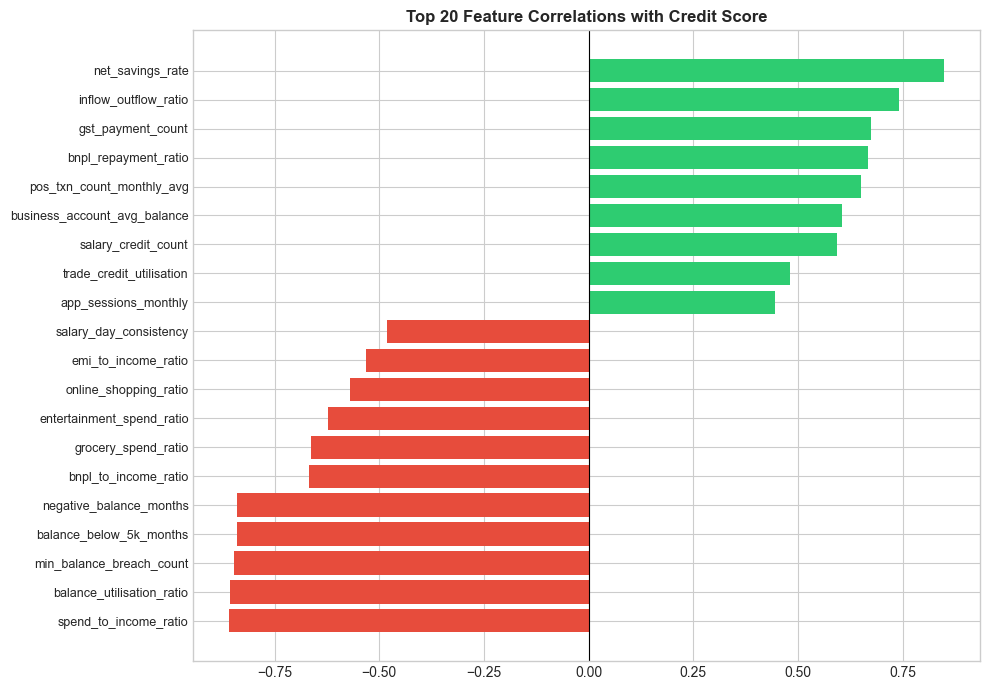

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_all['credit_score'], bins=50, color='steelblue', edgecolor='white', lw=0.4)
axes[0].axvline(df_all['credit_score'].mean(), color='red', ls='--',
                label=f"Mean={df_all['credit_score'].mean():.0f}")
for thr,col in [(750,'#2ecc71'),(650,'#f39c12'),(550,'#e74c3c')]:
    axes[0].axvline(thr, color=col, ls=':', lw=1.5)
axes[0].set_title('Credit Score Distribution (1 Lakh Users)', fontweight='bold')
axes[0].set_xlabel('Score (300–900)'); axes[0].legend()

utypes  = df_all['user_type'].unique()
data_bp = [df_all[df_all['user_type']==u]['credit_score'].values for u in utypes]
bp = axes[1].boxplot(data_bp, labels=utypes, patch_artist=True)
colors = plt.cm.Set2(np.linspace(0,1,len(utypes)))
for patch,c in zip(bp['boxes'],colors): patch.set_facecolor(c)
axes[1].set_title('Score by User Type', fontweight='bold')
axes[1].tick_params(axis='x', rotation=25)

bc = df_all['risk_band'].value_counts().sort_index()
bc_colors = {'A':'#2ecc71','B':'#f39c12','C':'#e67e22','D':'#e74c3c'}
axes[2].bar(bc.index, bc.values, color=[bc_colors[b] for b in bc.index], edgecolor='white')
for i,(b,cnt) in enumerate(bc.items()):
    axes[2].text(i, cnt+500, f'{cnt:,}\n({cnt/len(df_all)*100:.1f}%)',
                 ha='center', fontsize=8, fontweight='bold')
axes[2].set_title('Risk Band Distribution', fontweight='bold')

plt.suptitle('EDA — Full 1 Lakh Users', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation plot
corr   = df_all[feat_cols+['credit_score']].corr()['credit_score'].drop('credit_score')
top20  = corr.abs().nlargest(20).index
corr_v = corr[top20].sort_values()
fig, ax = plt.subplots(figsize=(10,7))
ax.barh(range(len(corr_v)), corr_v.values,
        color=['#e74c3c' if v<0 else '#2ecc71' for v in corr_v])
ax.set_yticks(range(len(corr_v)))
ax.set_yticklabels(corr_v.index, fontsize=9)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Top 20 Feature Correlations with Credit Score', fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔬 Step 3 — GMM Training on Full 1 Lakh Users
**GMM poore 1 lakh users pe train hoga** — yahi sahi approach hai!

Soft membership: ek user 40% Cluster-2 + 35% Cluster-5 ho sakta hai.

In [5]:
print(f'Scaling {len(df_all):,} users ...')
X_full        = df_all[feat_cols].copy()
scaler        = StandardScaler()
X_full_scaled = scaler.fit_transform(X_full)
print(f'✅ mean≈{X_full_scaled.mean():.3f}  std≈{X_full_scaled.std():.3f}')

Scaling 100,000 users ...
✅ mean≈0.000  std≈1.000


Finding optimal GMM components via BIC ...
  n= 4 | BIC=       95791 | AIC=       92077
  n= 5 | BIC=        5115 | AIC=         472
  n= 6 | BIC=     -226573 | AIC=     -232146
  n= 7 | BIC=     -246192 | AIC=     -252696
  n= 8 | BIC=     -292878 | AIC=     -300312
  n= 9 | BIC=     -339522 | AIC=     -347886
  n=10 | BIC=     -421530 | AIC=     -430824
  n=11 | BIC=     -413543 | AIC=     -423767
  n=12 | BIC=     -483394 | AIC=     -494548
  n=13 | BIC=     -495308 | AIC=     -507392
  n=14 | BIC=     -521281 | AIC=     -534296

✅ Optimal n_components = 14


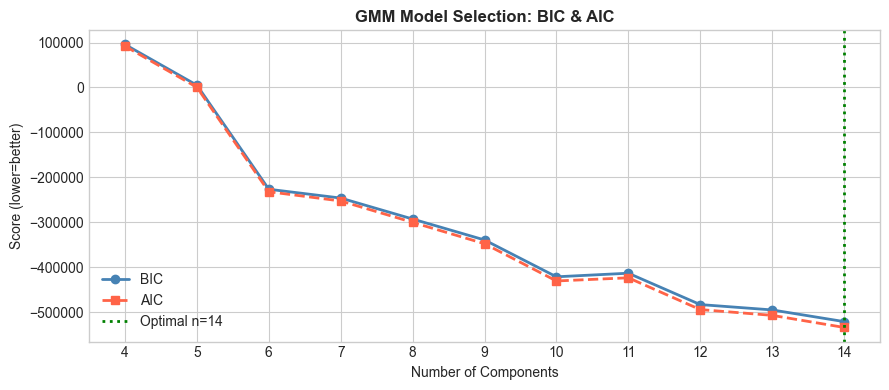

In [6]:
rng_sub = np.random.default_rng(42)
idx_sub = rng_sub.choice(len(X_full_scaled), 10_000, replace=False)
X_sub   = X_full_scaled[idx_sub]

print('Finding optimal GMM components via BIC ...')
bic_s, aic_s, n_range = [], [], range(4, 15)
for n in n_range:
    g = GaussianMixture(n_components=n,covariance_type='diag',random_state=42,max_iter=150,n_init=2)
    g.fit(X_sub)
    bic_s.append(g.bic(X_sub)); aic_s.append(g.aic(X_sub))
    print(f'  n={n:2d} | BIC={bic_s[-1]:>12.0f} | AIC={aic_s[-1]:>12.0f}')

optimal_n = list(n_range)[int(np.argmin(bic_s))]
print(f'\n✅ Optimal n_components = {optimal_n}')

fig,ax = plt.subplots(figsize=(9,4))
ax.plot(list(n_range),bic_s,'o-',color='steelblue',lw=2,label='BIC')
ax.plot(list(n_range),aic_s,'s--',color='tomato',lw=2,label='AIC')
ax.axvline(optimal_n,color='green',ls=':',lw=2,label=f'Optimal n={optimal_n}')
ax.set_xlabel('Number of Components'); ax.set_ylabel('Score (lower=better)')
ax.set_title('GMM Model Selection: BIC & AIC', fontweight='bold')
ax.legend(); ax.set_xticks(list(n_range))
plt.tight_layout()
plt.savefig('outputs/gmm_bic_aic.png',dpi=150,bbox_inches='tight'); plt.show()

Training GMM (n=14) on FULL 100,000 users ...
✅ Converged=True  log-likelihood=28.4479  (26s)

Cluster Profiles (trained on 1 lakh):
              avg_score  std_score  count    profile
gmm_cluster                                         
0            725.952268  28.805505   6348   LOW RISK
1            508.690711  25.977062   6502  HIGH RISK
2            564.451712  43.966198   6834  HIGH RISK
3            672.566615  33.962068   1929     MEDIUM
4            727.514367  28.039405   7065   LOW RISK
5            658.225224  30.477710   7699     MEDIUM
6            662.198767  28.514540   6490     MEDIUM
7            505.421855  25.672607   6360  HIGH RISK
8            652.894931  26.912912   6510     MEDIUM
9            686.857186  21.472074   9922     MEDIUM
10           635.271520  48.368160   6703     MEDIUM
11           574.640003  26.365765  13964  HIGH RISK
12           553.036683  38.995118   3135  HIGH RISK
13           655.505551  21.275931  10539     MEDIUM


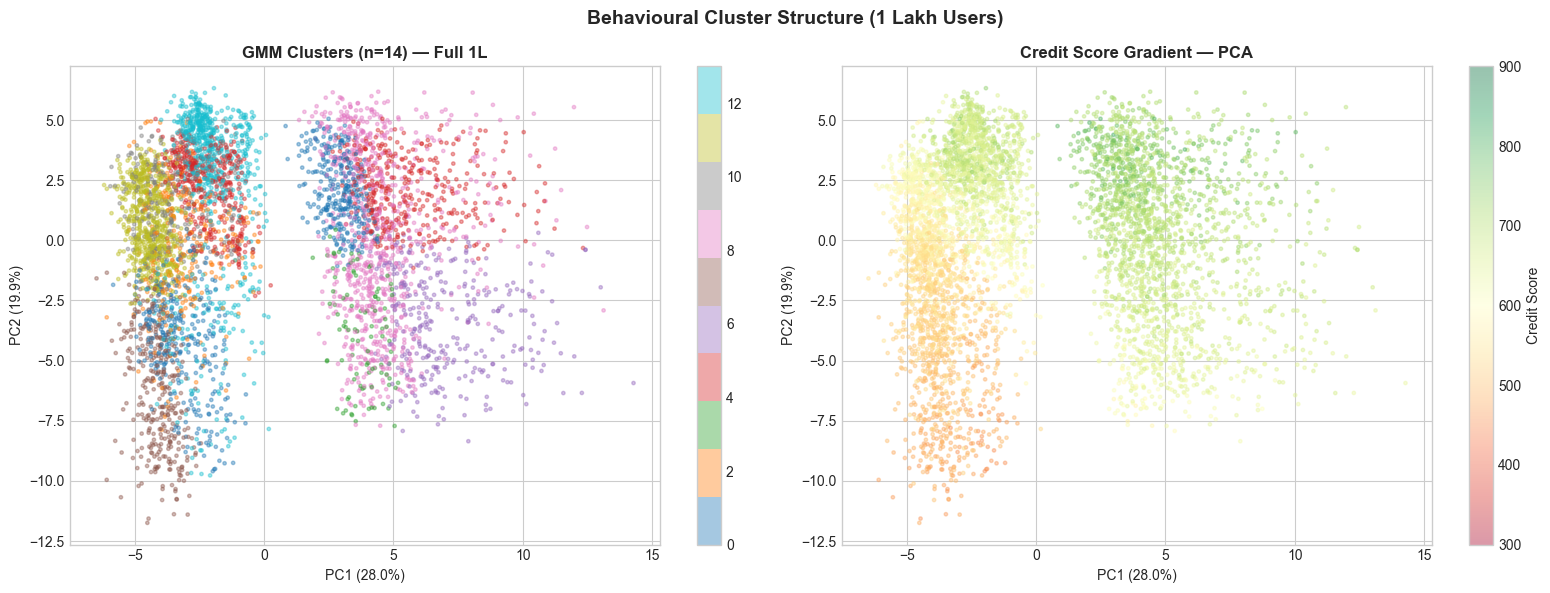

In [7]:
print(f'Training GMM (n={optimal_n}) on FULL {len(X_full_scaled):,} users ...')
t0  = time.time()
gmm = GaussianMixture(n_components=optimal_n,covariance_type='diag',
                      random_state=42,max_iter=400,n_init=3)
gmm.fit(X_full_scaled)
print(f'✅ Converged={gmm.converged_}  log-likelihood={gmm.lower_bound_:.4f}  ({time.time()-t0:.0f}s)')

hard_labels = gmm.predict(X_full_scaled)
df_c        = df_all.copy()
df_c['gmm_cluster'] = hard_labels
cprof = df_c.groupby('gmm_cluster')['credit_score'].agg(['mean','std','count'])
cprof.columns=['avg_score','std_score','count']
cprof['profile']=cprof['avg_score'].apply(lambda s:'LOW RISK' if s>=700 else('MEDIUM' if s>=580 else 'HIGH RISK'))
print('\nCluster Profiles (trained on 1 lakh):')
print(cprof.to_string())

pca   = PCA(n_components=2,random_state=42)
idx5k = np.random.choice(len(X_full_scaled),5000,replace=False)
X_pca = pca.fit_transform(X_full_scaled[idx5k])

fig,axes = plt.subplots(1,2,figsize=(16,6))
sc1=axes[0].scatter(X_pca[:,0],X_pca[:,1],c=hard_labels[idx5k],cmap='tab10',alpha=0.4,s=6)
axes[0].set_title(f'GMM Clusters (n={optimal_n}) — Full 1L',fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(sc1,ax=axes[0])
sc2=axes[1].scatter(X_pca[:,0],X_pca[:,1],c=df_all['credit_score'].values[idx5k],
                    cmap='RdYlGn',alpha=0.4,s=6,vmin=300,vmax=900)
axes[1].set_title('Credit Score Gradient — PCA',fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(sc2,ax=axes[1],label='Credit Score')
plt.suptitle('Behavioural Cluster Structure (1 Lakh Users)',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/gmm_clusters_pca.png',dpi=150,bbox_inches='tight'); plt.show()

## 🔧 Step 4 — 30% Missing Add Karo + GMM Imputation + QA Check
**Usi 1 lakh data mein** missing values add karo → GMM se fill karo → original se compare karo

In [8]:
imputable_cols = [c for c in feat_cols if c not in STRUCTURAL_ZERO_COLS]

def apply_missing(df, ratio, seed):
    rng=default_rng(seed); df=df.copy()
    for i in range(len(df)):
        n_miss=max(1,int(len(imputable_cols)*ratio))
        miss_c=rng.choice(imputable_cols,size=n_miss,replace=False)
        for col in miss_c: df.iloc[i,df.columns.get_loc(col)]=np.nan
    return df

print(f'Adding 30% missingness to {len(df_all):,} users ...')
t0 = time.time()
df_with_missing = apply_missing(df_all, 0.30, seed=42)
miss_avg = df_with_missing[feat_cols].isnull().mean().mean()*100
print(f'✅ Done in {time.time()-t0:.0f}s  |  Avg missing: {miss_avg:.1f}%')
print(f'   Total missing cells: {df_with_missing[feat_cols].isnull().sum().sum():,}')

Adding 30% missingness to 100,000 users ...
✅ Done in 809s  |  Avg missing: 26.6%
   Total missing cells: 1,700,000


In [11]:
def gmm_impute(df_in, gmm_model, scaler_obj, feat_cols):
    X        = df_in[feat_cols].copy().values.astype(float)
    mask     = np.isnan(X)
    has_miss = mask.any(axis=1)
    if not has_miss.any(): return df_in.copy()

    mu_s  = gmm_model.means_
    mu_o  = scaler_obj.inverse_transform(gmm_model.means_)
    cov   = gmm_model.covariances_
    log_w = np.log(gmm_model.weights_+1e-10)
    K     = gmm_model.n_components

    for i in np.where(has_miss)[0]:
        mc = np.where(mask[i])[0]
        oc = np.where(~mask[i])[0]
        if len(oc)==0:
            probs=np.exp(log_w-log_w.max()); probs/=probs.sum()
        else:
            tmp=X[i].copy(); tmp[mc]=mu_o[:,mc].mean(axis=0)
            ts=scaler_obj.transform(tmp.reshape(1,-1))[0]
            lp=log_w.copy()
            for k in range(K):
                d=ts[oc]-mu_s[k,oc]; v=cov[k,oc]+1e-6
                lp[k]+=-0.5*np.sum(d**2/v+np.log(2*np.pi*v))
            lp-=lp.max(); probs=np.exp(lp); probs/=probs.sum()
        X[i,mc]=probs@mu_o[:,mc]

    df_out=df_in.copy(); df_out[feat_cols]=X
    return df_out

print('✅ gmm_impute() defined')

✅ gmm_impute() defined


In [12]:
print(f'Running GMM imputation on {len(df_with_missing):,} users ...')
t0 = time.time()
df_imputed = gmm_impute(df_with_missing, gmm, scaler, feat_cols)

non_biz = df_with_missing['user_type'].isin(['salaried_private','salaried_govt','self_employed'])
for col in STRUCTURAL_ZERO_COLS:
    if col in feat_cols: df_imputed.loc[non_biz,col]=0.0

print(f'✅ Done in {time.time()-t0:.0f}s  |  Remaining NaNs: {df_imputed[feat_cols].isnull().sum().sum()}')

Running GMM imputation on 100,000 users ...
✅ Done in 34s  |  Remaining NaNs: 0


QA Check — Imputed values vs Original ground truth ...

  ═══ IMPUTATION QA RESULTS ════════════════════
  Features checked : 58
  Avg NMAE         : 11.01%  (lower=better)
  Avg R²           : 0.523  (higher=better)
  Best R²          : 0.999  ← upi_autopay_mandates
  Worst R²         : -0.000  ← weekend_spend_ratio
  NMAE < 10%       : 32 features ✅
  ════════════════════════════════════════════


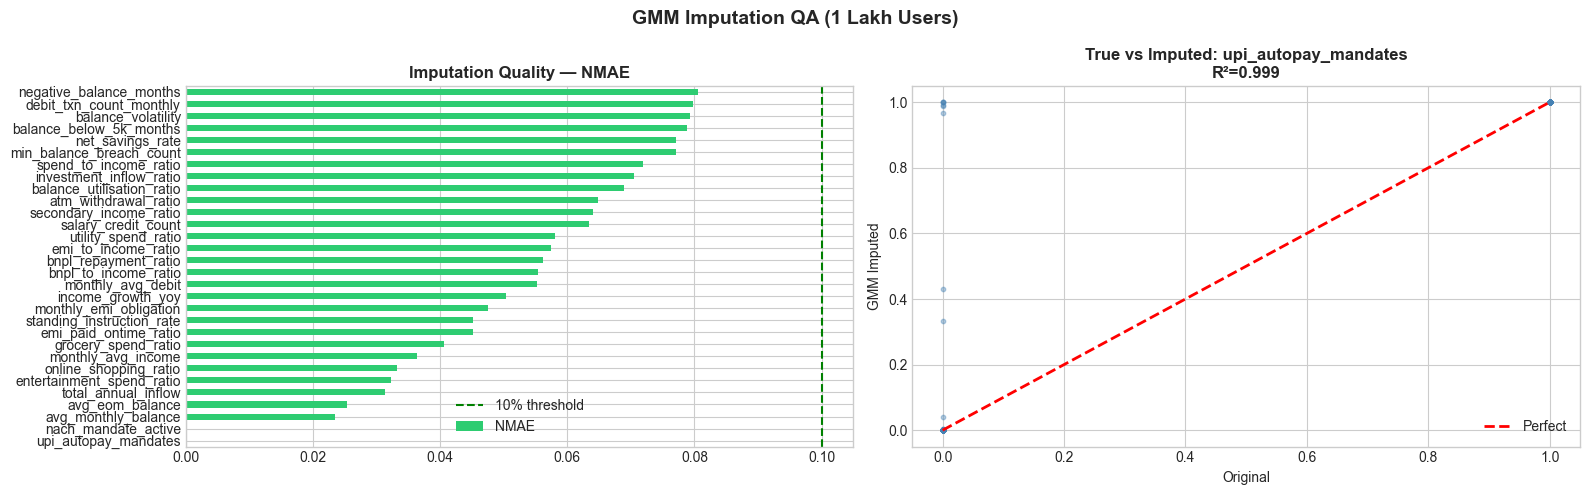

In [13]:
print('QA Check — Imputed values vs Original ground truth ...')
errors={}
for col in feat_cols:
    was_miss=df_with_missing[col].isnull()
    if was_miss.sum()<5: continue
    gt  = df_gt.loc[was_miss,col].values
    imp = df_imputed.loc[was_miss,col].values
    rng_col=float(gt.max()-gt.min())+1e-6
    errors[col]={'n':int(was_miss.sum()),
                 'MAE':float(mean_absolute_error(gt,imp)),
                 'NMAE':float(mean_absolute_error(gt,imp)/rng_col),
                 'R2':float(r2_score(gt,imp))}

err_df=pd.DataFrame(errors).T.sort_values('NMAE')
err_df.to_csv('outputs/imputation_qa.csv')

print(f'\n  ═══ IMPUTATION QA RESULTS ════════════════════')
print(f'  Features checked : {len(err_df)}')
print(f'  Avg NMAE         : {err_df["NMAE"].mean()*100:.2f}%  (lower=better)')
print(f'  Avg R²           : {err_df["R2"].mean():.3f}  (higher=better)')
print(f'  Best R²          : {err_df["R2"].max():.3f}  ← {err_df["R2"].idxmax()}')
print(f'  Worst R²         : {err_df["R2"].min():.3f}  ← {err_df["R2"].idxmin()}')
print(f'  NMAE < 10%       : {(err_df["NMAE"]<0.10).sum()} features ✅')
print(f'  ════════════════════════════════════════════')

fig,axes=plt.subplots(1,2,figsize=(16,5))
top30=err_df['NMAE'].sort_values().head(30)
top30.plot(kind='barh',ax=axes[0],
    color=['#2ecc71' if v<0.1 else('#f39c12' if v<0.2 else '#e74c3c') for v in top30])
axes[0].axvline(0.1,color='green',ls='--',lw=1.5,label='10% threshold')
axes[0].set_title('Imputation Quality — NMAE',fontweight='bold'); axes[0].legend()
best_f=err_df['R2'].idxmax(); rows_b=df_with_missing[best_f].isnull()
tv=df_gt.loc[rows_b,best_f]; iv=df_imputed.loc[rows_b,best_f]
axes[1].scatter(tv,iv,alpha=0.4,color='steelblue',s=10)
lims=[min(tv.min(),iv.min()),max(tv.max(),iv.max())]
axes[1].plot(lims,lims,'r--',lw=2,label='Perfect')
axes[1].set_title(f'True vs Imputed: {best_f}\nR²={err_df.loc[best_f,"R2"]:.3f}',fontweight='bold')
axes[1].set_xlabel('Original'); axes[1].set_ylabel('GMM Imputed'); axes[1].legend()
plt.suptitle('GMM Imputation QA (1 Lakh Users)',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/imputation_qa.png',dpi=150,bbox_inches='tight'); plt.show()

## 🤖 Step 5 — XGBoost Training on Full 1 Lakh (Imputed Data)
XGBoost **poore 1 lakh imputed users** pe train hoga!

In [14]:
le = LabelEncoder()
le.fit(df_all['user_type'])

def make_X(df,feat_cols,le):
    X=df[feat_cols].copy(); X['user_type_enc']=le.transform(df['user_type']); return X

X_all = make_X(df_imputed, feat_cols, le)
y_all = df_imputed['credit_score'].values

# 10% holdout for early stopping only
X_fit,X_hold,y_fit,y_hold = train_test_split(X_all,y_all,test_size=0.10,random_state=42)
print(f'XGBoost training : {X_fit.shape}  (from full 1 lakh imputed)')
print(f'Early stop hold  : {X_hold.shape}')
print(f'\nUser type distribution:')
print(df_imputed['user_type'].value_counts().to_string())

XGBoost training : (90000, 65)  (from full 1 lakh imputed)
Early stop hold  : (10000, 65)

User type distribution:
user_type
salaried_private    34857
shopkeeper          20226
businessman         18037
salaried_govt       14886
self_employed       11994


In [15]:
model = xgb.XGBRegressor(
    n_estimators=5000, learning_rate=0.03, max_depth=7,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
    reg_alpha=0.5, reg_lambda=2.0, random_state=42,
    eval_metric='rmse', early_stopping_rounds=40,
    tree_method='hist', verbosity=0,
)
print(f'Training XGBoost on {len(X_fit):,} users (full 1 lakh) ...')
t0=time.time()
model.fit(X_fit,y_fit,eval_set=[(X_hold,y_hold)],verbose=200)
print(f'\n✅ Best iteration: {model.best_iteration}  ({time.time()-t0:.0f}s)')

Training XGBoost on 90,000 users (full 1 lakh) ...
[0]	validation_0-rmse:73.62841
[200]	validation_0-rmse:7.67424
[400]	validation_0-rmse:6.74794
[600]	validation_0-rmse:6.29453
[800]	validation_0-rmse:6.00438
[1000]	validation_0-rmse:5.80687
[1200]	validation_0-rmse:5.64592
[1400]	validation_0-rmse:5.52904
[1600]	validation_0-rmse:5.43868
[1800]	validation_0-rmse:5.36837
[2000]	validation_0-rmse:5.30978
[2200]	validation_0-rmse:5.25470
[2400]	validation_0-rmse:5.21404
[2600]	validation_0-rmse:5.18037
[2800]	validation_0-rmse:5.15028
[3000]	validation_0-rmse:5.12635
[3200]	validation_0-rmse:5.10508
[3400]	validation_0-rmse:5.08972
[3600]	validation_0-rmse:5.07153
[3800]	validation_0-rmse:5.05780
[4000]	validation_0-rmse:5.04596
[4200]	validation_0-rmse:5.03592
[4400]	validation_0-rmse:5.02727
[4600]	validation_0-rmse:5.02029
[4800]	validation_0-rmse:5.01038
[4999]	validation_0-rmse:5.00108

✅ Best iteration: 4999  (116s)


## 📈 Step 6 — Evaluate + Bias Audit + SHAP

════════════════════════════════════════════════════
MODEL EVALUATION (10% holdout)
════════════════════════════════════════════════════
  MAE           : 3.55 score points
  RMSE          : 5.00
  R²            : 0.9956
  Band Accuracy : 96.6%
  AUC (Band A)  : 0.999
════════════════════════════════════════════════════


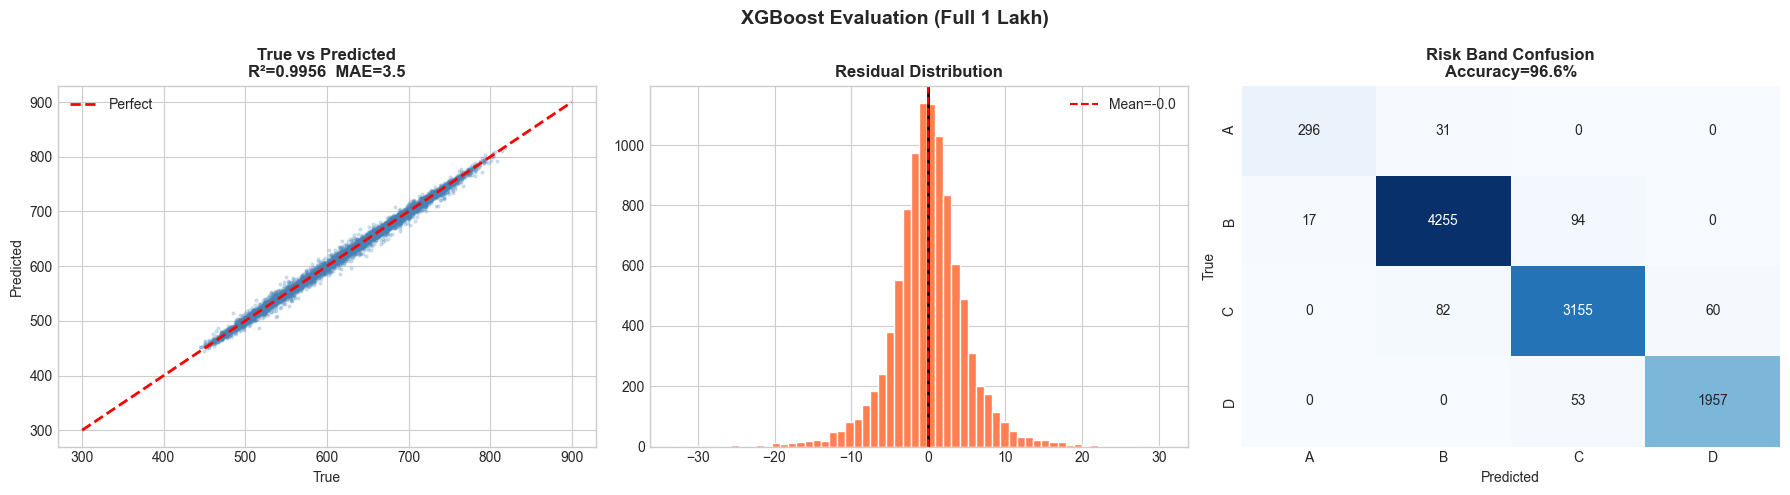

In [16]:
y_pred   = np.clip(model.predict(X_hold),300,900)
mae      = mean_absolute_error(y_hold,y_pred)
rmse     = float(np.sqrt(mean_squared_error(y_hold,y_pred)))
r2       = r2_score(y_hold,y_pred)
tb       = to_band(y_hold); pb=to_band(y_pred)
band_acc = float((tb==pb).mean())
try: auc=roc_auc_score((tb=='A').astype(int),np.clip((y_pred-300)/600,0,1))
except: auc=float('nan')

print('═'*52)
print('MODEL EVALUATION (10% holdout)')
print('═'*52)
print(f'  MAE           : {mae:.2f} score points')
print(f'  RMSE          : {rmse:.2f}')
print(f'  R²            : {r2:.4f}')
print(f'  Band Accuracy : {band_acc*100:.1f}%')
print(f'  AUC (Band A)  : {auc:.3f}')
print('═'*52)

fig,axes=plt.subplots(1,3,figsize=(18,5))
axes[0].scatter(y_hold,y_pred,alpha=0.2,s=4,color='steelblue')
axes[0].plot([300,900],[300,900],'r--',lw=2,label='Perfect')
axes[0].set_title(f'True vs Predicted\nR²={r2:.4f}  MAE={mae:.1f}',fontweight='bold')
axes[0].set_xlabel('True'); axes[0].set_ylabel('Predicted'); axes[0].legend()
resid=y_pred-y_hold
axes[1].hist(resid,bins=60,color='coral',edgecolor='white',lw=0.3)
axes[1].axvline(0,color='black',lw=2)
axes[1].axvline(resid.mean(),color='red',ls='--',label=f'Mean={resid.mean():.1f}')
axes[1].set_title('Residual Distribution',fontweight='bold'); axes[1].legend()
cm=confusion_matrix(tb,pb,labels=['A','B','C','D'])
sns.heatmap(cm,annot=True,fmt='d',xticklabels=['A','B','C','D'],
            yticklabels=['A','B','C','D'],cmap='Blues',ax=axes[2],cbar=False)
axes[2].set_title(f'Risk Band Confusion\nAccuracy={band_acc*100:.1f}%',fontweight='bold')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('True')
plt.suptitle('XGBoost Evaluation (Full 1 Lakh)',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/model_evaluation.png',dpi=150,bbox_inches='tight'); plt.show()

── Bias Audit: MAE by User Type ────────────────
  businessman             MAE=3.6  n=1807
  salaried_govt           MAE=3.6  n=1473
  salaried_private        MAE=3.5  n=3517
  self_employed           MAE=3.5  n=1206
  shopkeeper              MAE=3.5  n=1997


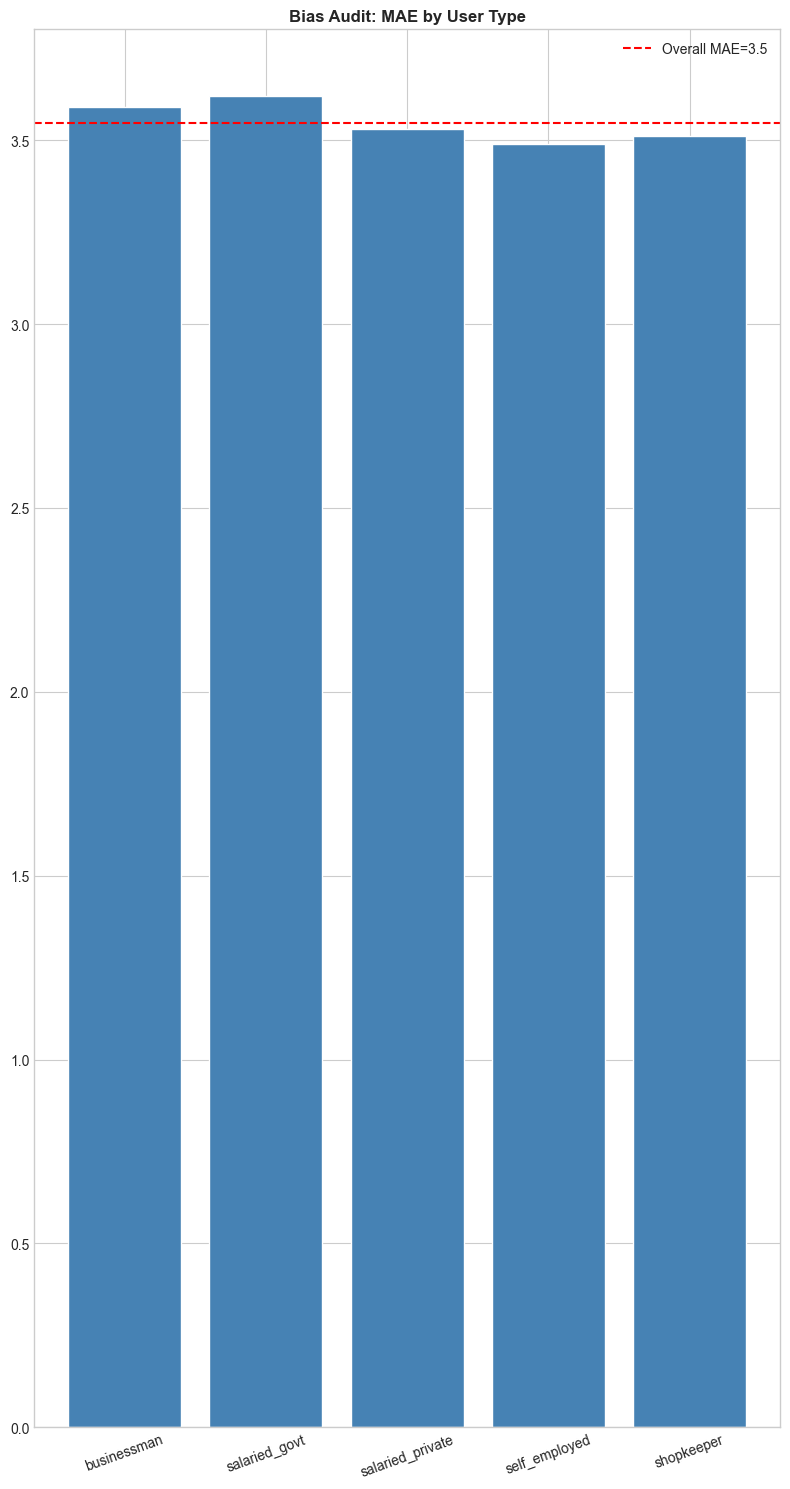

In [19]:
print('── Bias Audit: MAE by User Type ────────────────')
hold_types = df_imputed['user_type'].values[len(X_fit):]
bias_rows  = []
for ut in np.unique(hold_types):
    m=(hold_types==ut)
    if m.sum()<10: continue
    mae_ut=mean_absolute_error(y_hold[m],y_pred[m])
    bias_rows.append({'user_type':ut,'n':int(m.sum()),'MAE':round(mae_ut,2)})
    print(f'  {ut:22s}  MAE={mae_ut:.1f}  n={m.sum()}')

bias_df=pd.DataFrame(bias_rows)
fig,ax=plt.subplots(figsize=(8,15))
ax.bar(bias_df['user_type'],bias_df['MAE'],color='steelblue',edgecolor='white')
ax.axhline(mae,color='red',ls='--',label=f'Overall MAE={mae:.1f}')
ax.set_title('Bias Audit: MAE by User Type',fontweight='bold')
ax.tick_params(axis='x',rotation=20); ax.legend()
plt.tight_layout()
plt.savefig('outputs/bias_audit.png',dpi=150,bbox_inches='tight'); plt.show()

Computing SHAP values (500 sample) ...


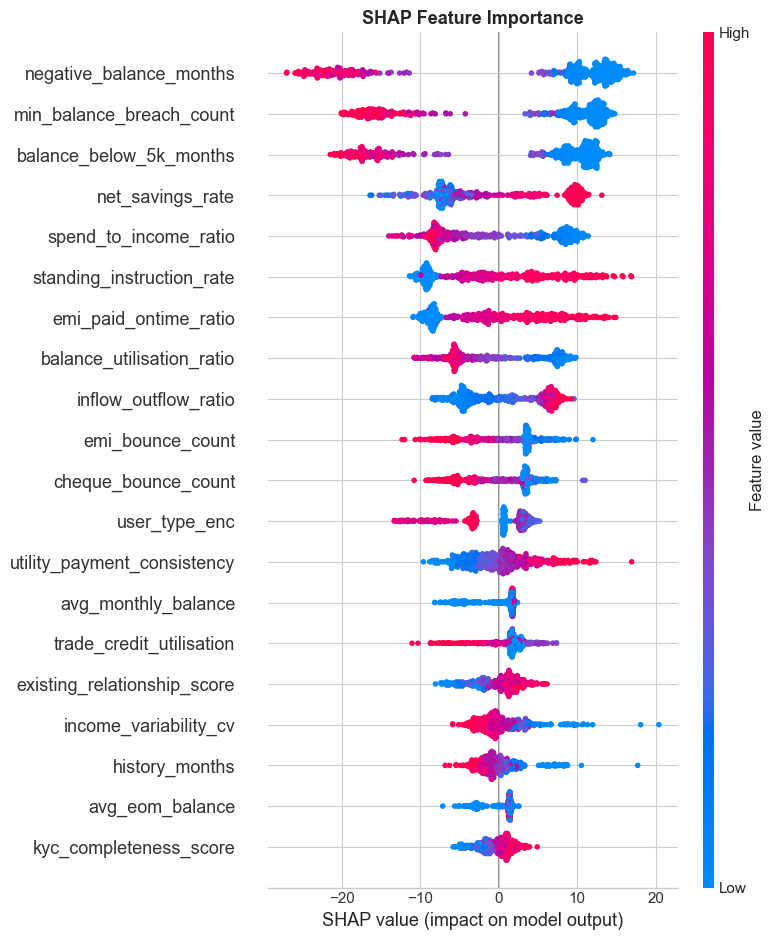

In [20]:
try:
    import shap
    print('Computing SHAP values (500 sample) ...')
    explainer=shap.TreeExplainer(model)
    X_shap=X_hold.sample(500,random_state=42) if hasattr(X_hold,'sample') else pd.DataFrame(X_hold).sample(500,random_state=42)
    shap_vals=explainer.shap_values(X_shap)
    plt.figure(figsize=(10,8))
    shap.summary_plot(shap_vals,X_shap,max_display=20,show=False)
    plt.title('SHAP Feature Importance',fontweight='bold',fontsize=13)
    plt.tight_layout()
    plt.savefig('outputs/shap_summary.png',dpi=150,bbox_inches='tight'); plt.show()
except ImportError:
    print('pip install shap')

## 🎯 Step 7 — Test Set Predictions (10k New Users)
Yeh **brand new users** hain — model ne inhe kabhi nahi dekha!

Test set: 10,000 new users  |  missing: 21.9%
Imputing test set via GMM ...
✅ Done in 4s

  ═══ TEST RESULTS (10,000 new users) ════════════
  Score range    : 445 – 818
  Mean score     : 628
  MAE vs truth   : 3.07
  Band Accuracy  : 96.9%
  Bands:
A     289
B    4354
C    3392
D    1965
  Decisions:
loan_decision
APPROVE_LOWER_LIMIT    4354
MANUAL_REVIEW          3392
REJECT                 1965
AUTO_APPROVE            289

✅ Saved → outputs/predictions_output.csv


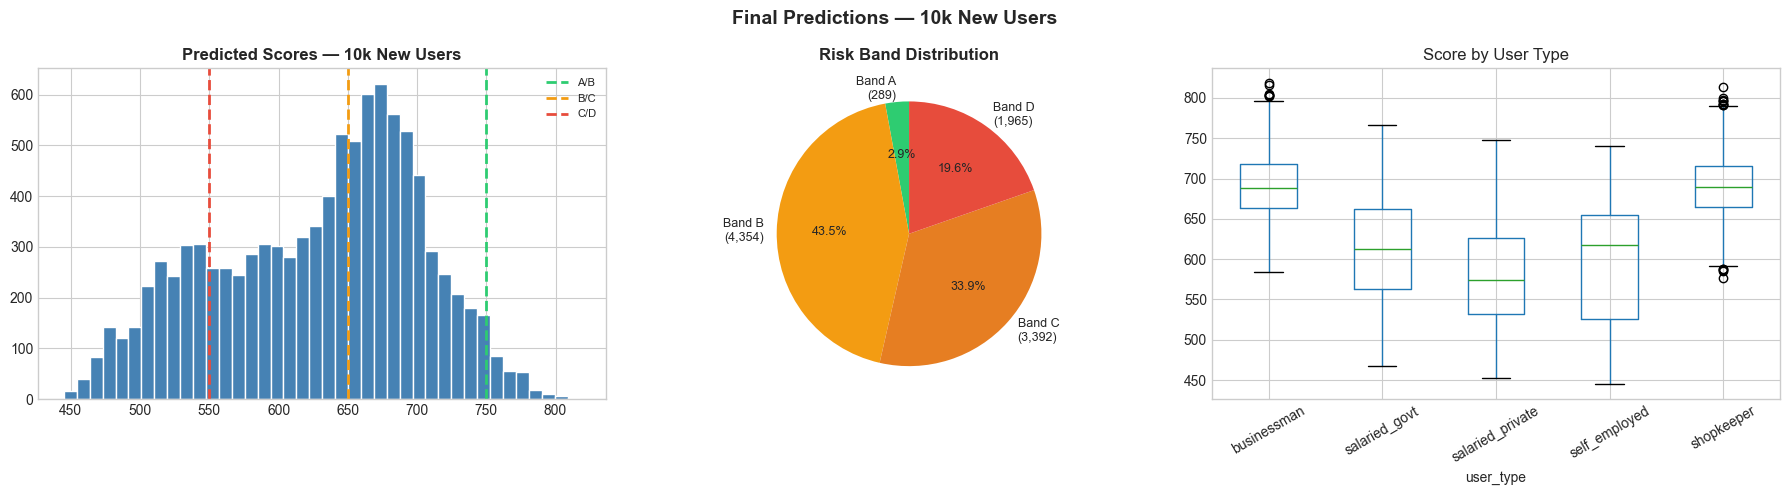

In [21]:
print(f'Test set: {len(df_test):,} new users  |  missing: {df_test[feat_cols].isnull().mean().mean()*100:.1f}%')

for col in feat_cols:
    if col not in df_test.columns: df_test[col]=np.nan

print('Imputing test set via GMM ...')
t0=time.time()
df_test_imp = gmm_impute(df_test, gmm, scaler, feat_cols)
non_biz_t   = df_test['user_type'].isin(['salaried_private','salaried_govt','self_employed'])
for col in STRUCTURAL_ZERO_COLS:
    if col in feat_cols: df_test_imp.loc[non_biz_t,col]=0.0
print(f'✅ Done in {time.time()-t0:.0f}s')

X_test    = make_X(df_test_imp,feat_cols,le)
raw       = model.predict(X_test)
scores    = np.clip(np.round(raw).astype(int),300,900)
bands     = to_band(scores)
decisions = pd.Series(bands).map({'A':'AUTO_APPROVE','B':'APPROVE_LOWER_LIMIT',
                                   'C':'MANUAL_REVIEW','D':'REJECT'}).values

results = df_test_imp[['user_id','user_type']].copy()
results['predicted_score']=scores
results['risk_band']=bands
results['loan_decision']=decisions
results.to_csv('outputs/predictions_output.csv',index=False)

# Compare vs ground truth
true_scores   = df_test_gt['credit_score'].values
test_mae      = mean_absolute_error(true_scores,scores)
test_band_acc = float((to_band(true_scores)==bands).mean())

print(f'\n  ═══ TEST RESULTS ({len(results):,} new users) ════════════')
print(f'  Score range    : {scores.min()} – {scores.max()}')
print(f'  Mean score     : {scores.mean():.0f}')
print(f'  MAE vs truth   : {test_mae:.2f}')
print(f'  Band Accuracy  : {test_band_acc*100:.1f}%')
print(f'  Bands:\n{pd.Series(bands).value_counts().sort_index().to_string()}')
print(f'  Decisions:\n{results["loan_decision"].value_counts().to_string()}')
print(f'\n✅ Saved → outputs/predictions_output.csv')

fig,axes=plt.subplots(1,3,figsize=(18,5))
axes[0].hist(scores,bins=40,color='steelblue',edgecolor='white',lw=0.4)
for thr,lbl,col in [(750,'A/B','#2ecc71'),(650,'B/C','#f39c12'),(550,'C/D','#e74c3c')]:
    axes[0].axvline(thr,color=col,ls='--',lw=2,label=lbl)
axes[0].set_title('Predicted Scores — 10k New Users',fontweight='bold'); axes[0].legend(fontsize=8)
bc2=pd.Series(bands).value_counts().sort_index()
pc={'A':'#2ecc71','B':'#f39c12','C':'#e67e22','D':'#e74c3c'}
axes[1].pie(bc2.values,labels=[f'Band {b}\n({c:,})' for b,c in bc2.items()],
            colors=[pc[b] for b in bc2.index],autopct='%1.1f%%',startangle=90,textprops={'fontsize':9})
axes[1].set_title('Risk Band Distribution',fontweight='bold')
results.boxplot(column='predicted_score',by='user_type',ax=axes[2])
axes[2].set_title('Score by User Type',fontweight='bold')
axes[2].tick_params(axis='x',rotation=30); plt.sca(axes[2]); plt.title('Score by User Type')
fig.suptitle('Final Predictions — 10k New Users',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/final_predictions.png',dpi=150,bbox_inches='tight'); plt.show()

## 🚀 Step 8 — Save Models + Real-Time Scoring

In [22]:
joblib.dump(scaler,    'models/scaler.pkl')
joblib.dump(gmm,       'models/gmm_model.pkl')
joblib.dump(model,     'models/xgb_model.pkl')
joblib.dump(le,        'models/label_encoder.pkl')
joblib.dump(feat_cols, 'models/feature_cols.pkl')
joblib.dump(STRUCTURAL_ZERO_COLS,'models/structural_zero_cols.pkl')
print('✅ All models saved to models/')

✅ All models saved to models/


In [23]:
# Models load once — production safe
_sc=joblib.load('models/scaler.pkl'); _gmm=joblib.load('models/gmm_model.pkl')
_mdl=joblib.load('models/xgb_model.pkl'); _le=joblib.load('models/label_encoder.pkl')
_fc=joblib.load('models/feature_cols.pkl'); _zc=joblib.load('models/structural_zero_cols.pkl')

def score_new_user(feat_dict, user_type):
    row=np.array([feat_dict.get(c,np.nan) for c in _fc],dtype=float)
    mask=np.isnan(row); mi=np.where(mask)[0]; oi=np.where(~mask)[0]
    imputed=[_fc[i] for i in mi]
    if len(mi)>0:
        mu_s=_gmm.means_; mu_o=_sc.inverse_transform(_gmm.means_)
        cv=_gmm.covariances_; lw=np.log(_gmm.weights_+1e-10); K=_gmm.n_components
        if len(oi)==0:
            probs=np.exp(lw-lw.max()); probs/=probs.sum()
        else:
            tmp=row.copy(); tmp[mi]=mu_o[:,mi].mean(axis=0)
            ts=_sc.transform(tmp.reshape(1,-1))[0]; lp=lw.copy()
            for k in range(K):
                d=ts[oi]-mu_s[k,oi]; v=cv[k,oi]+1e-6
                lp[k]+=-0.5*np.sum(d**2/v+np.log(2*np.pi*v))
            lp-=lp.max(); probs=np.exp(lp); probs/=probs.sum()
        row[mi]=probs@mu_o[:,mi]
        if user_type not in ['shopkeeper','businessman']:
            for col in _zc:
                if col in _fc: row[_fc.index(col)]=0.0
    X=pd.DataFrame([dict(zip(_fc,row))])
    X['user_type_enc']=_le.transform([user_type])
    X=X[_fc+['user_type_enc']]
    raw=float(_mdl.predict(X)[0])
    score=int(np.clip(round(raw),300,900))
    band='A' if score>=750 else('B' if score>=650 else('C' if score>=550 else 'D'))
    dec={'A':'AUTO_APPROVE','B':'APPROVE_LOWER_LIMIT','C':'MANUAL_REVIEW','D':'REJECT'}[band]
    cp=_gmm.predict_proba(_sc.transform(row.reshape(1,-1)))[0]
    f=dict(zip(_fc,row))
    def c(x): return float(np.clip(x,0,1))
    dims={
        'Income stability':   round(c(f.get('salary_day_consistency',0)*0.4+f.get('net_savings_rate',0)*0.3)*100,1),
        'Balance behaviour':  round(c(1-f.get('balance_utilisation_ratio',0.5))*100,1),
        'Spending discipline':round(c(1-f.get('spend_to_income_ratio',0.7))*100,1),
        'EMI repayment':      round(c(f.get('emi_paid_ontime_ratio',0.5))*100,1),
        'Bill payments':      round(c(f.get('utility_payment_consistency',0.5))*100,1),
        'Savings':            round(c(f.get('net_savings_rate',0)/0.55+0.18)*100,1),
        'BNPL behaviour':     round(c(f.get('bnpl_repayment_ratio',0.8))*100,1),
    }
    sd=sorted(dims.items(),key=lambda x:x[1],reverse=True)
    return {'credit_score':score,'risk_band':band,'loan_decision':dec,
            'top_positive_factors':dict(sd[:3]),'top_negative_factors':dict(sd[-3:]),
            'cluster_membership':{f'C{i}':round(float(p),3) for i,p in sorted(enumerate(cp),key=lambda x:x[1],reverse=True)[:3]},
            'imputed_features':imputed}

print('✅ score_new_user() ready')

✅ score_new_user() ready


In [24]:
demo_users = [
    {'name':'Rahul — Good salaried','type':'salaried_private',
     'feat':{'monthly_avg_income':75000,'salary_day_consistency':0.95,
             'emi_paid_ontime_ratio':0.97,'net_savings_rate':0.30,
             'utility_payment_consistency':0.92,'cheque_bounce_count':0,
             'account_vintage_months':60}},
    {'name':'Suresh — Struggling shopkeeper','type':'shopkeeper',
     'feat':{'monthly_avg_income':25000,'spend_to_income_ratio':0.95,
             'emi_bounce_count':4,'net_savings_rate':-0.05,'cheque_bounce_count':3}},
    {'name':'Priya — Govt employee','type':'salaried_govt',
     'feat':{'monthly_avg_income':55000,'salary_day_consistency':1.0,
             'emi_paid_ontime_ratio':1.0,'net_savings_rate':0.25,
             'account_vintage_months':120,'cheque_bounce_count':0}},
]

for u in demo_users:
    print(f'\n{"─"*55}')
    print(f'  {u["name"]}')
    out=score_new_user(u['feat'],u['type'])
    print(f'  Credit Score  : {out["credit_score"]} / 900')
    print(f'  Risk Band     : {out["risk_band"]}')
    print(f'  Decision      : {out["loan_decision"]}')
    print(f'  +ve Factors   : {out["top_positive_factors"]}')
    print(f'  -ve Factors   : {out["top_negative_factors"]}')
    print(f'  Clusters      : {out["cluster_membership"]}')
    print(f'  GMM filled    : {len(out["imputed_features"])} features')


───────────────────────────────────────────────────────
  Rahul — Good salaried
  Credit Score  : 682 / 900
  Risk Band     : B
  Decision      : APPROVE_LOWER_LIMIT
  +ve Factors   : {'BNPL behaviour': 98.2, 'EMI repayment': 97.0, 'Bill payments': 92.0}
  -ve Factors   : {'Income stability': 47.0, 'Balance behaviour': 0.0, 'Spending discipline': 0.0}
  Clusters      : {'C10': 1.0, 'C12': 0.0, 'C0': 0.0}
  GMM filled    : 57 features

───────────────────────────────────────────────────────
  Suresh — Struggling shopkeeper
  Credit Score  : 601 / 900
  Risk Band     : C
  Decision      : MANUAL_REVIEW
  +ve Factors   : {'BNPL behaviour': 98.1, 'EMI repayment': 89.8, 'Bill payments': 72.3}
  -ve Factors   : {'Savings': 8.9, 'Spending discipline': 5.0, 'Balance behaviour': 0.0}
  Clusters      : {'C10': 1.0, 'C12': 0.0, 'C0': 0.0}
  GMM filled    : 59 features

───────────────────────────────────────────────────────
  Priya — Govt employee
  Credit Score  : 659 / 900
  Risk Band     : B


## ✅ Pipeline Summary

| Step | Task | Data |
|------|------|------|
| 1 | Load data | all_users.csv (1 lakh) |
| 2 | EDA | 1 lakh users |
| 3 | **GMM Training** | **Full 1 lakh** ✅ |
| 4 | **30% missing → impute → QA** | **Full 1 lakh** ✅ |
| 5 | **XGBoost Training** | **Full 1 lakh imputed** ✅ |
| 6 | Evaluate + Bias Audit + SHAP | 10% holdout |
| 7 | Test Predictions | **10k NEW users** ✅ |
| 8 | Save + Real-time scoring | Any new user |

**Key improvement:** GMM aur XGBoost dono poore 1 lakh users pe train hote hain — pehle sirf 70k pe hote the!